<a href="https://colab.research.google.com/github/RapoluUma956/Navigation-and-Sensor-data-error-minimization-using-AI/blob/main/LSTM_attitude_Estimation_1/LSTM_Attitude_Estimation_Using_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Import Libraries**

In [ ]:
from numpy import array
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Dense
from tensorflow.keras.layers import Flatten, LSTM, Conv1D, RNN, SimpleRNN
from tensorflow.keras.layers import GlobalMaxPooling1D, Bidirectional
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Embedding
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Concatenate
from tensorflow.keras.layers import Bidirectional
from sklearn import preprocessing
from tensorflow.keras import regularizers
from sklearn.metrics import mean_squared_error
from math import sqrt
import pandas as pd
import numpy as np
import re
from tensorflow.keras.utils import plot_model
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt
import math
from scipy.io import loadmat
import time

## **Import Data**

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/LSTM-DRDO/D6.xlsx')
df.head()
data1=np.array(df)
print(data1.shape)
data=data1[0:data1.shape[0],:]
print(data.shape)

(34862, 12)
(34862, 12)


In [ ]:
dataX = data[:,0:9];
dataY = data[:,9:12]

min_max_scaler = preprocessing.MinMaxScaler()
dataX = min_max_scaler.fit_transform(dataX)

## **Split Training and Testing Data**

In [ ]:
split = 10000
dataXt = dataX[:split]
dataYt = dataY[:split]
dataXv = dataX[split:]
dataYv = dataY[split:]

input_dim = dataXt.shape[1]

print("input_dim:", input_dim)
print("\nTraining Testing")
print(dataXt.shape[0],dataXv.shape[0])

timestep = 2
Xphithetapsi = dataXt
Xphithetapsi = array(Xphithetapsi).reshape(split//timestep, timestep, input_dim)
Yphithetapsi = array(dataYt[0::timestep])
print("Xphithetapsi shape",Xphithetapsi.shape)
print("Yphithetapsi shape",Yphithetapsi.shape)

input_dim: 9

Training Testing
10000 24862
Xphithetapsi shape (5000, 2, 9)
Yphithetapsi shape (5000, 3)


## **Model desing and Training**

In [ ]:
inputs = Input(name='inputs',shape=[timestep,input_dim])
layer = LSTM(50, return_sequences=True)(inputs)
layer = Dropout(0.25)(layer)
layer = LSTM(20)(layer)
outputs = Dense(3, activation='linear')(layer)

modelphithetapsi1 = Model(inputs=[inputs],outputs=[outputs])

# Compile
modelphithetapsi1.compile(optimizer='RMSprop', loss='mean_squared_error',metrics = ['accuracy'])
modelphithetapsi1.summary()

history = modelphithetapsi1.fit(Xphithetapsi, Yphithetapsi,
                       epochs=20,
                       verbose=0,
                       batch_size=50)

print('Model Training done')

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputs (InputLayer)             │ (None, 2, 9)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ (None, 2, 50)          │        12,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 2, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 20)             │         5,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            63 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,743 (69.31 KB)

 Trainable params: 17,743 (69.31 KB)

 Non-trainable params: 0 (0.00 B)

Model Training done


## **Offline Predictions**

In [ ]:
results = []

Xtestt = dataXv
Ytestt = dataYv

usable_len = (len(Xtestt) // timestep) * timestep

Xtestt = Xtestt[:usable_len]
Ytestt = Ytestt[:usable_len]

Ytest = np.array(Ytestt[0::timestep])
Xtest = np.array(Xtestt[:, 0:9])

ip = Xtest.reshape(usable_len // timestep, timestep, input_dim)

test_output = modelphithetapsi1.predict(ip)

results = np.array(test_output)
print("results shape:", results.shape)
print("Ytest shape:", Ytest.shape)

389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
results shape: (12431, 3)
Ytest shape: (12431, 3)


## **Incremental Learning Model**

In [ ]:
# new model for incremental learning
model = Model(inputs=[inputs],outputs=[outputs])
model.compile(optimizer='RMSprop', loss='mean_squared_error',metrics = ['accuracy'])
model.summary()
#copy weights
Wsave = modelphithetapsi1.get_weights()
model.set_weights(Wsave)

wgt = model.get_weights()
print(wgt[1])

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputs (InputLayer)             │ (None, 2, 9)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ (None, 2, 50)          │        12,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 2, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 20)             │         5,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            63 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,743 (69.31 KB)

 Trainable params: 17,743 (69.31 KB)

 Non-trainable params: 0 (0.00 B)

[[-0.17291102 -0.04584324 -0.08782778 ... -0.06912566 -0.1535518
   0.09742542]
 [-0.08012694 -0.01271575 -0.01141316 ... -0.04581374 -0.15734428
   0.09858517]
 [-0.00883807  0.01400465 -0.03771892 ... -0.22996418 -0.12678792
   0.12559453]
 ...
 [-0.35143054 -0.21626996 -0.2558702  ...  0.00512843 -0.13925374
   0.03061663]
 [-0.1665694  -0.07273936 -0.10011839 ... -0.07373663 -0.08845835
  -0.03090068]
 [-0.1465777  -0.29252163 -0.09879326 ... -0.07869093 -0.1475478
  -0.10497757]]


In [ ]:
result = []

stepinit = 3000
timestep = 2
input_dim = 9

total_test_rows = dataXv.shape[0]
num_chunks = total_test_rows // stepinit
araya = [stepinit] * num_chunks

print("Total test rows:", total_test_rows)
print("Full chunks:", num_chunks)

for j in range(num_chunks):
    pt = stepinit * j

    Xtestt = dataXv[pt:pt + stepinit]
    Ytestt = dataYv[pt:pt + stepinit]

    usable_len = (len(Xtestt) // timestep) * timestep

    Xtestt = Xtestt[:usable_len]
    Ytestt = Ytestt[:usable_len]

    Xtest = np.array(Xtestt[:, 0:9])
    Ytest = np.array(Ytestt[0::timestep])

    ip = Xtest.reshape(usable_len // timestep, timestep, input_dim)

    test_output = model.predict(ip)
    result.append(test_output)

    start = time.time()
    history = model.fit(
        ip,
        Ytest,
        epochs=20,
        verbose=0,
        batch_size=50
    )
    end = time.time()

    print("Training time:", end - start)

if len(result) > 0:
    result = np.vstack(result)
else:
    result = np.empty((0, 3))

print("result shape:", result.shape)


# remaining data block
result1 = []

pt = stepinit * num_chunks
step = total_test_rows - pt

print("Remaining step:", step)

if step > 0:
    Xtestt = dataXv[pt:pt + step]
    Ytestt = dataYv[pt:pt + step]

    usable_len = (len(Xtestt) // timestep) * timestep

    if usable_len > 0:
        Xtestt = Xtestt[:usable_len]
        Ytestt = Ytestt[:usable_len]

        Xtest = np.array(Xtestt[:, 0:9])
        Ytest = np.array(Ytestt[0::timestep])

        ip = Xtest.reshape(usable_len // timestep, timestep, input_dim)

        test_output = model.predict(ip)
        result1.append(test_output)

        result1 = np.vstack(result1)
    else:
        result1 = np.empty((0, 3))
else:
    result1 = np.empty((0, 3))

print("result1 shape:", result1.shape)


# combine both
if result1.shape[0] > 0:
    results = np.vstack((result, result1))
else:
    results = result

print("Final results shape:", results.shape)

Total test rows: 24862
Full chunks: 8
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Training time: 5.383615970611572
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training time: 5.325826406478882
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training time: 3.952669382095337
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training time: 3.9555938243865967
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training time: 5.332722902297974
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training time: 3.6709742546081543
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training time: 3.986560583114624
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training time: 5.159234046936035
result shape: (12000, 3)
Remaining step: 862
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
result1 shape: (431, 3)
Final results shape: (12431, 3)


In [ ]:
print(result.shape)
print(result1.shape)

results = np.vstack((result,result1))
print(results.shape)

(12000, 3)
(431, 3)
(12431, 3)


## **Compute RMSE and Print Results**

Yt shape: (12431, 3)
test_output shape: (12431, 3)
Final Yt shape: (12431, 3)
Final test_output shape: (12431, 3)
RMSE phi/roll: 1.3674803910535123
RMSE theta/pitch: 0.5020310214242146
RMSE psi/yaw: 1.0386754244436243
MAE phi/roll: 0.5907479756776851
MAE theta/pitch: 0.2820648683242014
MAE psi/yaw: 0.5213919143241801
R2 phi/roll: 0.4609670443102032
R2 theta/pitch: 0.6255858935278218
R2 psi/yaw: 0.4670306088773224


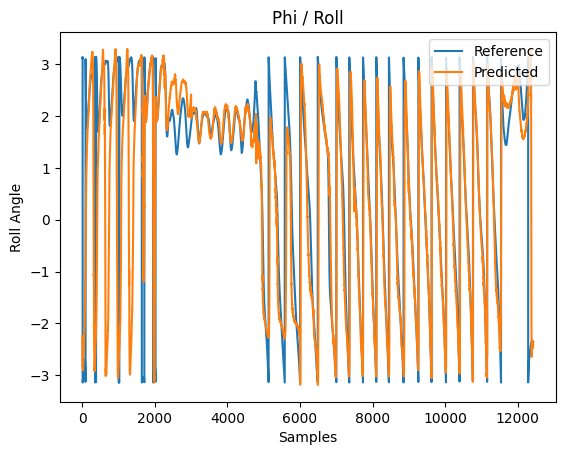

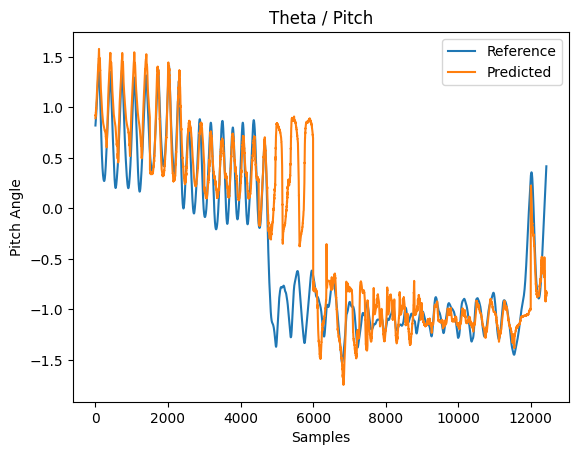

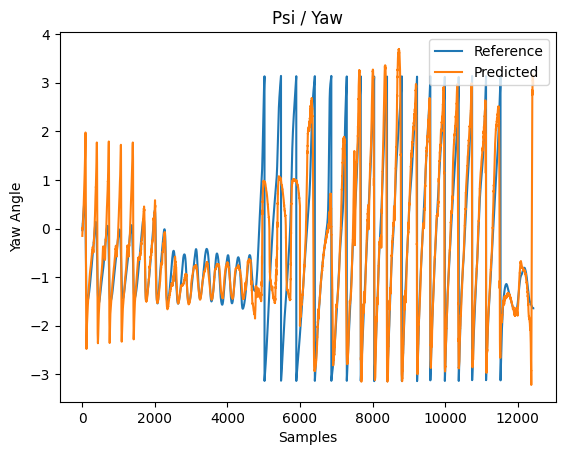

In [ ]:
Yt = np.array(dataYv[0::timestep])
test_output = np.array(results)

print("Yt shape:", Yt.shape)
print("test_output shape:", test_output.shape)

# match lengths
min_len = min(Yt.shape[0], test_output.shape[0])

Yt = Yt[:min_len]
test_output = test_output[:min_len]

print("Final Yt shape:", Yt.shape)
print("Final test_output shape:", test_output.shape)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt

rmsephi = sqrt(mean_squared_error(Yt[:, 0], test_output[:, 0]))
rmsetheta = sqrt(mean_squared_error(Yt[:, 1], test_output[:, 1]))
rmsepsi = sqrt(mean_squared_error(Yt[:, 2], test_output[:, 2]))

maephi = mean_absolute_error(Yt[:, 0], test_output[:, 0])
maetheta = mean_absolute_error(Yt[:, 1], test_output[:, 1])
maepsi = mean_absolute_error(Yt[:, 2], test_output[:, 2])

r2phi = r2_score(Yt[:, 0], test_output[:, 0])
r2theta = r2_score(Yt[:, 1], test_output[:, 1])
r2psi = r2_score(Yt[:, 2], test_output[:, 2])

print("RMSE phi/roll:", rmsephi)
print("RMSE theta/pitch:", rmsetheta)
print("RMSE psi/yaw:", rmsepsi)

print("MAE phi/roll:", maephi)
print("MAE theta/pitch:", maetheta)
print("MAE psi/yaw:", maepsi)

print("R2 phi/roll:", r2phi)
print("R2 theta/pitch:", r2theta)
print("R2 psi/yaw:", r2psi)

plt.plot(Yt[:, 0])
plt.plot(test_output[:, 0])
plt.title('Phi / Roll')
plt.xlabel('Samples')
plt.ylabel('Roll Angle')
plt.legend(['Reference', 'Predicted'], loc='upper right')
plt.show()

plt.plot(Yt[:, 1])
plt.plot(test_output[:, 1])
plt.title('Theta / Pitch')
plt.xlabel('Samples')
plt.ylabel('Pitch Angle')
plt.legend(['Reference', 'Predicted'], loc='upper right')
plt.show()

plt.plot(Yt[:, 2])
plt.plot(test_output[:, 2])
plt.title('Psi / Yaw')
plt.xlabel('Samples')
plt.ylabel('Yaw Angle')
plt.legend(['Reference', 'Predicted'], loc='upper right')
plt.show()